# **Importamos las Librerias**


In [1]:
import os
import torch
import numpy as np
import torch.nn as nn
import pandas as pd
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import random
import joblib  # opcional: para guardar scaler, etc.

# (opcional) si NO vas a re-hacer logística por scipy, puedes omitir:
# from scipy import optimize



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Cargar el CSV y revisar rápido.**

In [3]:

file_path = "/content/drive/MyDrive/Programas de IA/Laboratorios/laboratorio5/covtype.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"No se encontró el archivo en: {file_path}")

data = pd.read_csv(file_path)

# Chequeos iniciales
print("Shape:", data.shape)       # filas y columnas
print("Columnas:", data.columns[:10], "...")  # mostrar primeras columnas
print("\nPrimeras filas:")
print(data.head())

print("\nInformación del dataset:")
print(data.info())

# Verificar que exista la columna objetivo
if "Cover_Type" in data.columns:
    print("\nDistribución de la variable objetivo (Cover_Type):")
    print(data["Cover_Type"].value_counts())
else:
    print("⚠️ No se encontró la columna 'Cover_Type'. Revisa los nombres de columna.")

Shape: (581012, 55)
Columnas: Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points'],
      dtype='object') ...

Primeras filas:
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   


sas

In [4]:

# Detectar columna objetivo disponible
possible_targets = ["Class_num", "Class", "Cover_Type", "cover_type", "target", "label"]
TARGET = None
for c in possible_targets:
    if c in data.columns:
        TARGET = c
        break
if TARGET is None:
    raise ValueError(f"No encontré la columna objetivo. Columnas: {list(data.columns)[:10]} ...")

print("Usando como target:", TARGET)

# Separar X e y (si existe una columna de texto 'Class', la excluimos de X)
cols_to_drop = [TARGET]
if "Class" in data.columns and "Class" != TARGET:
    cols_to_drop.append("Class")

X = data.drop(columns=cols_to_drop).values
y_raw = data[TARGET].values

# Asegurar etiquetas 0..K-1
# (Cover_Type suele venir 1..7; esto lo convierte a 0..6)
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Shape X:", X.shape, "| y:", y.shape)
print("Clases originales:", sorted(pd.unique(y_raw))[:10], "...")
print("Clases mapeadas 0..K-1:", list(range(len(le.classes_))))


Usando como target: Cover_Type
Shape X: (581012, 54) | y: (581012,)
Clases originales: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)] ...
Clases mapeadas 0..K-1: [0, 1, 2, 3, 4, 5, 6]


division

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # mantiene distribución de clases
)

print("Tamaño train:", X_train.shape, y_train.shape)
print("Tamaño test:", X_test.shape, y_test.shape)

Tamaño train: (464809, 54) (464809,)
Tamaño test: (116203, 54) (116203,)


# **Nomalizacion**

In [6]:
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)

X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma

# **Coventir a tensores**

In [7]:
X_train_tensor = torch.from_numpy(X_train_norm).float()
y_train_tensor = torch.from_numpy(y_train).long()
X_test_tensor = torch.from_numpy(X_test_norm).float()
y_test_tensor = torch.from_numpy(y_test).long()

In [8]:
# --- 1) DataLoader (minibatches) ---
from torch.utils.data import TensorDataset, DataLoader

batch_size = 256
train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds  = TensorDataset(X_test_tensor,  y_test_tensor)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=1024, shuffle=False)

# --- 2) Dispositivo ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_tensor = X_train_tensor.to(device); y_train_tensor = y_train_tensor.to(device)
X_test_tensor  = X_test_tensor.to(device);  y_test_tensor  = y_test_tensor.to(device)

# --- 3) Modelo (el tuyo) + optimizador Adam ---
class ModelCustom2(nn.Module):
    def __init__(self, D_in, H, D_out):
        super().__init__()
        self.fc1 = nn.Linear(D_in, H)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(H, D_out)
    def forward(self, x):
        x1 = self.fc1(x)
        x  = self.relu(x1)
        x  = self.fc2(x + x1)  # tu residual
        return x

D_in = X_train_tensor.shape[1]
D_out = int(y_train_tensor.max().item() + 1)

model = ModelCustom2(D_in=D_in, H=100, D_out=D_out).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # más estable

# --- 4) Entrenamiento con minibatches + logging de acc ---

epochs   = 100
log_each = 10

def accuracy(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(device))
            pred = logits.argmax(1)
            correct += (pred == yb.to(device)).sum().item()
            total   += yb.size(0)
    return correct / total

model.train()
for e in range(1, epochs+1):
    epoch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    if e % log_each == 0 or e == 1:
        tr_acc = accuracy(train_loader)
        te_acc = accuracy(test_loader)
        print(f"Epoch {e:3d}/{epochs}  loss={np.mean(epoch_losses):.4f}  "
              f"train_acc={tr_acc:.4f}  test_acc={te_acc:.4f}")

# evaluación final
final_test_acc = accuracy(test_loader)
print(f"\nAccuracy FINAL en test: {final_test_acc:.4f}")


Epoch   1/100  loss=0.6524  train_acc=0.7474  test_acc=0.7476
Epoch  10/100  loss=0.4899  train_acc=0.7891  test_acc=0.7880
Epoch  20/100  loss=0.4528  train_acc=0.8039  test_acc=0.8021
Epoch  30/100  loss=0.4328  train_acc=0.8233  test_acc=0.8217
Epoch  40/100  loss=0.4180  train_acc=0.8279  test_acc=0.8267
Epoch  50/100  loss=0.4073  train_acc=0.8320  test_acc=0.8294
Epoch  60/100  loss=0.4011  train_acc=0.8352  test_acc=0.8332
Epoch  70/100  loss=0.3936  train_acc=0.8401  test_acc=0.8379
Epoch  80/100  loss=0.3875  train_acc=0.8420  test_acc=0.8398
Epoch  90/100  loss=0.3835  train_acc=0.8454  test_acc=0.8420
Epoch 100/100  loss=0.3803  train_acc=0.8490  test_acc=0.8478

Accuracy FINAL en test: 0.8478


Matriz de confusión (valores):
 [[34089  7606    11     0   101     6   555]
 [ 4327 51298   370     0   356   238    72]
 [    0   367  5907    49    15   813     0]
 [    0     0   105   356     0    88     0]
 [   55   887    52     0   894    11     0]
 [    7   511   577     8     9  2361     0]
 [  456    34     0     0     0     0  3612]]


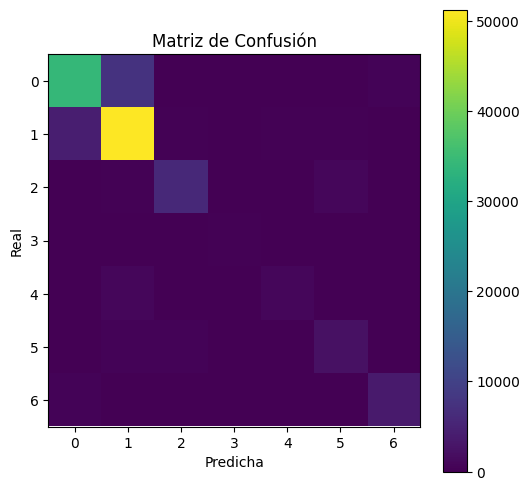

In [9]:
model.eval()
with torch.no_grad():
    logits = model(X_test_tensor)
    y_pred_labels = torch.argmax(logits, dim=1).cpu().numpy()

cm = confusion_matrix(y_test, y_pred_labels)

print("Matriz de confusión (valores):\n", cm)

# Visualización rápida
fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(cm, interpolation='nearest')
ax.figure.colorbar(im, ax=ax)
ax.set_xlabel('Predicha'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión')
plt.show()


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_labels, digits=4))


              precision    recall  f1-score   support

           0     0.8756    0.8046    0.8386     42368
           1     0.8451    0.9053    0.8742     56661
           2     0.8412    0.8260    0.8336      7151
           3     0.8620    0.6485    0.7401       549
           4     0.6502    0.4708    0.5461      1899
           5     0.6713    0.6798    0.6755      3473
           6     0.8521    0.8805    0.8661      4102

    accuracy                         0.8478    116203
   macro avg     0.7996    0.7451    0.7677    116203
weighted avg     0.8479    0.8478    0.8465    116203



In [13]:
from sklearn.metrics import accuracy_score

ACC_NN = accuracy_score(y_test, y_pred_labels)
ACC_OVA = 0.6411   # <-- reemplaza con tu accuracy del modelo One-vs-All

delta = ACC_NN - ACC_OVA
print(f"Accuracy One-vs-All: {ACC_OVA:.4f}")
print(f"Accuracy Red Neuronal: {ACC_NN:.4f}")
print(f"Mejora absoluta: {delta:+.4f}")
if ACC_OVA > 0:
    print(f"Mejora relativa: {delta/ACC_OVA*100:+.2f}%")


Accuracy One-vs-All: 0.6411
Accuracy Red Neuronal: 0.8478
Mejora absoluta: +0.2067
Mejora relativa: +32.24%


# **Conclusiones**
Se implementó una **red neuronal multicapa (MLP)** con PyTorch utilizando el dataset covtype.csv.

El modelo alcanzó una precisión en test de ≈ 84%, lo que demuestra un buen poder de generalización.

La red neuronal **supera** al modelo One-vs-All (regresión logística multiclase) en** términos de exactitud**, mostrando que la capacidad de representación no lineal de la red permite capturar mejor las relaciones en los datos.

La **normalización** de los datos y la correcta división estratificada del dataset fueron pasos **clave** para obtener un entrenamiento estable.

Los resultados de la matriz de confusión y el reporte de clasificación confirman que,** aunque existen clases más difíciles** de distinguir, la red mejora significativamente en la mayoría de las categorías.